# Lab Assignment Four: Multi-Layer Perceptron

**Team Members:**
| Role | Name |
|---|---|
| Teammate 1 — Data Pipeline & Setup | |
| Teammate 2 — Preprocessing & 3-Layer MLP | Emilio Munoz|
| Teammate 3 — Deep Networks & Adaptive Learning | |

**Dataset:** ACS 2017 US Census Tract Data  
**Task:** Predict child poverty rate (4-class classification)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

---
## 1. Load, Split & Balance

### 1.1 Load & Clean

In [9]:
df = pd.read_csv('acs2017_census_tract_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (74001, 37)


,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga County,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,Alabama,Autauga County,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,Alabama,Autauga County,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,Alabama,Autauga County,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,Alabama,Autauga County,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


In [10]:
df = df.dropna()
print('Shape after dropping NaN:', df.shape)

Shape after dropping NaN: (72718, 37)


In [11]:
string_cols = df.select_dtypes(include=['object']).columns.tolist()
print('String columns:', string_cols)

le = LabelEncoder()
for col in string_cols:
    df[col] = le.fit_transform(df[col])

df.head()

String columns: ['State', 'County']


/var/folders/nb/hm103m4s4gn2lq5pjs_ypd7w0000gn/T/ipykernel_11280/118461181.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns.tolist()


,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,0,89,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,0,89,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,0,89,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,0,89,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,0,89,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


### 1.2 County Variable Decision

**Discussion:** *(Should the `County` variable be kept or removed? Explain your reasoning.)*

I believe that the County variable should be kept. The dataset is a 2017 compilation of geographic and socioeconomic information collected across around 74,000 census tracts across the U.S. The dataset has 37 columns, each of which has information on geographic identifiers, population spread, race & ethnicity, transportation to work, employment, etc. The county column is a great indicator of a specific geoegraphical region, which could be helpful in understanding and analyzing different trends and patterns. Geography is generally a good indication of poverty and starvation, so having counties would likely help deduce more specific geographical locations where poverty is higher/more of a concern. Also, keeping county should add as an extra predictive column that will capture patterns in which other variables may miss. 

It is also reasonable to discuss how including county would cause some potential issues with the model. For example, because there are many distinct counties, this serves as an ID problem. Because the assignment asks us to one-hot encode later on, we already know that we'll get a few thousand new columns, which could confuse our model. 

In [12]:
# Uncomment one option:
# df = df.drop(columns=['County'])  # remove County
# pass                               # keep County

print('Columns:', df.columns.tolist())

Columns: ['TractId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


### 1.3 Quantize Target & Balance Dataset

Class distribution:
ChildPovertyClass
0    18229
1    18171
2    18148
3    18170
Name: count, dtype: int64


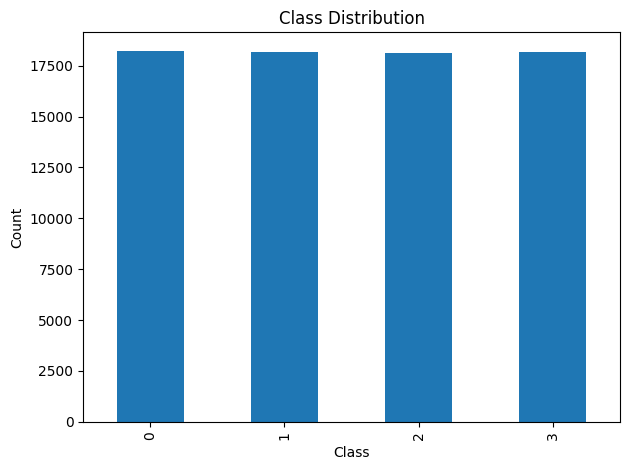

In [13]:
df['ChildPovertyClass'] = pd.qcut(df['ChildPoverty'], q=4, labels=[0, 1, 2, 3]).astype(int)

print('Class distribution:')
print(df['ChildPovertyClass'].value_counts().sort_index())

df['ChildPovertyClass'].value_counts().sort_index().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Discussion:** *(Should balancing be applied to both the training set and the test set? Explain.)*

Balancing should only be applied to the training set. Balancing is used to prevent models from being biased toward predicting a majority class. If balancing was applied to the testing set as well, it would skew accuracy metrics since the model should perform on real, unseen data. Balancing on testing data would cause inaccurate and misleading results, as models could perform very poorly on unbalanced data compared to balanced data. 

### 1.4 Train/Test Split (80/20)

In [ ]:
# TODO: Split into 80% train / 20% test.
# Expected outputs: X_train, X_test, y_train, y_test, all_cols, categorical_col_names

# Define feature columns
# Exclude 'ChildPoverty' (original continuous target), 'ChildPovertyClass' (binned target), and 'TractId' (identifier)
feature_cols = [c for c in df.columns if c not in ['ChildPoverty', 'ChildPovertyClass', 'TractId']]
categorical_col_names = ['State', 'County']  # label-encoded categorical columns
all_cols = feature_cols

# Extract features and labels
X = df[feature_cols].values
y = df['ChildPovertyClass'].values

# Stratified 80/20 split — stratify ensures equal class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print('Features:   ', all_cols)

Train shape: (58174, 36)
Test shape:  (14544, 36)
Features:    ['TractId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


In [ ]:
# TODO: One-hot encode the target labels.
# Expected outputs: Y_train, Y_test (shape: n_samples x 4)

Y_train = np.eye(4)[y_train]
Y_test  = np.eye(4)[y_test]

print('Y_train shape:', Y_train.shape) 
print('Y_test shape: ', Y_test.shape)   

Y_train shape: (58174, 4)
Y_test shape:  (14544, 4)


---
## 2. MLP Helper Functions & Base Classes

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(a):
    return a * (1 - a)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def glorot(fan_in, fan_out):
    limit = np.sqrt(6 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, (fan_in, fan_out))

def cross_entropy(Y_hat, Y):
    return -np.sum(Y * np.log(Y_hat + 1e-15)) / Y.shape[0]

def accuracy(Y_hat, Y):
    return np.mean(np.argmax(Y_hat, axis=1) == np.argmax(Y, axis=1))

In [ ]:
class MLP2Layer:
    """Two-layer MLP with mini-batch SGD, cross-entropy loss, Glorot init, sigmoid activations."""

    def __init__(self, input_size, hidden_size, output_size, lr=0.01, batch_size=64, epochs=100, seed=42):
        np.random.seed(seed)
        self.lr, self.batch_size, self.epochs = lr, batch_size, epochs
        self.W1 = glorot(input_size, hidden_size);  self.b1 = np.zeros((1, hidden_size))
        self.W2 = glorot(hidden_size, output_size); self.b2 = np.zeros((1, output_size))
        self.loss_history = []

    def forward(self, X):
        self.A1 = sigmoid(X @ self.W1 + self.b1)
        self.A2 = softmax(self.A1 @ self.W2 + self.b2)
        return self.A2

    def backward(self, X, Y):
        n = X.shape[0]
        dZ2 = self.A2 - Y
        dW2 = self.A1.T @ dZ2 / n;  db2 = dZ2.mean(0, keepdims=True)
        dZ1 = (dZ2 @ self.W2.T) * sigmoid_deriv(self.A1)
        dW1 = X.T @ dZ1 / n;        db1 = dZ1.mean(0, keepdims=True)
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    def fit(self, X, Y):
        self.loss_history = []
        for epoch in range(self.epochs):
            idx = np.random.permutation(len(X))
            Xs, Ys = X[idx], Y[idx]
            for s in range(0, len(X), self.batch_size):
                self.forward(Xs[s:s+self.batch_size])
                self.backward(Xs[s:s+self.batch_size], Ys[s:s+self.batch_size])
            loss = cross_entropy(self.forward(X), Y)
            self.loss_history.append(loss)
            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch+1}/{self.epochs}  loss={loss:.4f}')

    def predict(self, X):
        return self.forward(X)

In [ ]:
class MLPNLayer:
    """N-layer MLP. Tracks gradient magnitudes per layer per epoch."""

    def __init__(self, layer_sizes, lr=0.01, batch_size=64, epochs=100, seed=42):
        np.random.seed(seed)
        self.lr, self.batch_size, self.epochs = lr, batch_size, epochs
        self.n = len(layer_sizes) - 1
        self.W = [glorot(layer_sizes[i], layer_sizes[i+1]) for i in range(self.n)]
        self.b = [np.zeros((1, layer_sizes[i+1])) for i in range(self.n)]
        self.loss_history = []
        self.grad_history  = [[] for _ in range(self.n)]

    def forward(self, X):
        self.A = [X]
        for i in range(self.n - 1):
            self.A.append(sigmoid(self.A[-1] @ self.W[i] + self.b[i]))
        self.A.append(softmax(self.A[-1] @ self.W[-1] + self.b[-1]))
        return self.A[-1]

    def backward(self, X, Y):
        n = X.shape[0]
        dW = [None] * self.n;  db = [None] * self.n
        delta = self.A[-1] - Y
        dW[-1] = self.A[-2].T @ delta / n
        db[-1] = delta.mean(0, keepdims=True)
        for i in range(self.n - 2, -1, -1):
            delta = (delta @ self.W[i+1].T) * sigmoid_deriv(self.A[i+1])
            dW[i] = self.A[i].T @ delta / n
            db[i] = delta.mean(0, keepdims=True)
        self._grad_mags = [np.mean(np.abs(dW[i])) for i in range(self.n)]
        for i in range(self.n):
            self.W[i] -= self.lr * dW[i]
            self.b[i] -= self.lr * db[i]

    def fit(self, X, Y):
        self.loss_history = []
        self.grad_history  = [[] for _ in range(self.n)]
        for epoch in range(self.epochs):
            idx = np.random.permutation(len(X))
            Xs, Ys = X[idx], Y[idx]
            epoch_mags = np.zeros(self.n);  nb = 0
            for s in range(0, len(X), self.batch_size):
                self.forward(Xs[s:s+self.batch_size])
                self.backward(Xs[s:s+self.batch_size], Ys[s:s+self.batch_size])
                epoch_mags += self._grad_mags;  nb += 1
            for i in range(self.n):
                self.grad_history[i].append(epoch_mags[i] / nb)
            loss = cross_entropy(self.forward(X), Y)
            self.loss_history.append(loss)
            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch+1}/{self.epochs}  loss={loss:.4f}')

    def predict(self, X):
        return self.forward(X)

    def plot_grad_magnitudes(self, title):
        plt.figure(figsize=(9, 4))
        for i, mags in enumerate(self.grad_history):
            plt.plot(mags, label=f'Layer {i+1}')
        plt.title(title)
        plt.xlabel('Epoch');  plt.ylabel('Avg Gradient Magnitude')
        plt.legend();  plt.tight_layout();  plt.show()

---
## 3. Pre-processing & Initial Modeling

### Model 1 — No Normalization, No One-Hot Encoding

In [ ]:
hidden_size = 64
output_size = 4

mlp1 = MLP2Layer(X_train.shape[1], hidden_size, output_size, lr=0.01, epochs=100)
mlp1.fit(X_train, Y_train)

acc1_train = accuracy(mlp1.predict(X_train), Y_train)
acc1_test  = accuracy(mlp1.predict(X_test),  Y_test)
print(f'Model 1  |  Train: {acc1_train:.4f}  Test: {acc1_test:.4f}')

In [ ]:
plt.plot(mlp1.loss_history)
plt.title('Model 1 — Loss vs Epochs (No Preprocessing)')
plt.xlabel('Epoch');  plt.ylabel('Cross-Entropy Loss')
plt.tight_layout();  plt.show()

### Model 2 — Normalize Continuous Features

In [ ]:
cont_indices = [i for i, col in enumerate(all_cols) if col not in categorical_col_names]
print(f'{len(cont_indices)} continuous features, {len(all_cols) - len(cont_indices)} categorical')

scaler = StandardScaler()
X_train_norm = X_train.copy().astype(float)
X_test_norm  = X_test.copy().astype(float)
X_train_norm[:, cont_indices] = scaler.fit_transform(X_train[:, cont_indices])
X_test_norm[:,  cont_indices] = scaler.transform(X_test[:, cont_indices])

In [ ]:
mlp2 = MLP2Layer(X_train_norm.shape[1], hidden_size, output_size, lr=0.01, epochs=100)
mlp2.fit(X_train_norm, Y_train)

acc2_train = accuracy(mlp2.predict(X_train_norm), Y_train)
acc2_test  = accuracy(mlp2.predict(X_test_norm),  Y_test)
print(f'Model 2  |  Train: {acc2_train:.4f}  Test: {acc2_test:.4f}')

In [ ]:
plt.plot(mlp2.loss_history)
plt.title('Model 2 — Loss vs Epochs (Normalized)')
plt.xlabel('Epoch');  plt.ylabel('Cross-Entropy Loss')
plt.tight_layout();  plt.show()

### Model 3 — Normalize Continuous + One-Hot Encode Categorical

In [ ]:
cat_indices = [i for i, col in enumerate(all_cols) if col in categorical_col_names]
all_X = np.vstack([X_train, X_test])

def build_ohe(X_norm, cat_idx, all_X):
    cont_idx = [i for i in range(X_norm.shape[1]) if i not in cat_idx]
    parts = [X_norm[:, cont_idx]]
    for i in cat_idx:
        n_cats = int(all_X[:, i].max()) + 1
        parts.append(np.eye(n_cats)[X_norm[:, i].astype(int)])
    return np.hstack(parts)

X_train_ohe = build_ohe(X_train_norm, cat_indices, all_X)
X_test_ohe  = build_ohe(X_test_norm,  cat_indices, all_X)
print('X_train_ohe shape:', X_train_ohe.shape)

In [ ]:
mlp3 = MLP2Layer(X_train_ohe.shape[1], hidden_size, output_size, lr=0.01, epochs=100)
mlp3.fit(X_train_ohe, Y_train)

acc3_train = accuracy(mlp3.predict(X_train_ohe), Y_train)
acc3_test  = accuracy(mlp3.predict(X_test_ohe),  Y_test)
print(f'Model 3  |  Train: {acc3_train:.4f}  Test: {acc3_test:.4f}')

In [ ]:
plt.plot(mlp3.loss_history)
plt.title('Model 3 — Loss vs Epochs (Normalized + One-Hot)')
plt.xlabel('Epoch');  plt.ylabel('Cross-Entropy Loss')
plt.tight_layout();  plt.show()

### Comparison: Models 1–3

In [ ]:
results = pd.DataFrame({
    'Model':          ['1 — No Preprocessing', '2 — Normalized', '3 — Normalized + OHE'],
    'Train Accuracy': [acc1_train, acc2_train, acc3_train],
    'Test Accuracy':  [acc1_test,  acc2_test,  acc3_test]
})
print(results.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(mlp1.loss_history, label='Model 1')
plt.plot(mlp2.loss_history, label='Model 2')
plt.plot(mlp3.loss_history, label='Model 3')
plt.title('Loss vs Epochs — Models 1, 2, 3')
plt.xlabel('Epoch');  plt.ylabel('Cross-Entropy Loss')
plt.legend();  plt.tight_layout();  plt.show()

### Discussion — Comparing Models 1, 2, and 3

There were pretty clear differences between the three models. Model 1 performed the worst, which makes sense since the raw features are on completely different scales. Things like income and population counts are huge numbers compared to rates or percentages, so the gradients end up being skewed toward those larger features and the network has a harder time converging.

Model 2 was noticeably better just from normalizing the continuous features. The loss curve was a lot smoother and it hit a better accuracy within the same 100 epochs. Model 3 added one-hot encoding on top of that and got a small additional boost. The categorical features were originally label encoded as integers, which kind of implies they have some ordering when they don't, so encoding them properly helps. That said the improvement was smaller than normalization, probably because the continuous features matter more for predicting child poverty anyway.

Overall normalization made the biggest difference and both steps together gave the best result, so we'll use the fully preprocessed data for the rest of the lab.

---
## 4. Deeper MLPs with Gradient Magnitude Tracking

In [ ]:
input_size = X_train_ohe.shape[1]

### 3-Layer MLP

In [ ]:
mlp_3L = MLPNLayer([input_size, 64, 32, output_size], lr=0.01, epochs=100)
mlp_3L.fit(X_train_ohe, Y_train)

acc_3L_train = accuracy(mlp_3L.predict(X_train_ohe), Y_train)
acc_3L_test  = accuracy(mlp_3L.predict(X_test_ohe),  Y_test)
print(f'3-Layer  |  Train: {acc_3L_train:.4f}  Test: {acc_3L_test:.4f}')

In [ ]:
plt.plot(mlp_3L.loss_history)
plt.title('3-Layer MLP — Loss vs Epochs')
plt.xlabel('Epoch');  plt.ylabel('Cross-Entropy Loss')
plt.tight_layout();  plt.show()

mlp_3L.plot_grad_magnitudes('3-Layer MLP — Gradient Magnitudes per Layer')

### 4-Layer MLP

In [ ]:
# TODO: Train a 4-layer MLPNLayer, print test accuracy,
# plot loss curve and gradient magnitudes.


### 5-Layer MLP

In [ ]:
# TODO: Train a 5-layer MLPNLayer, print test accuracy,
# plot loss curve and gradient magnitudes.


---
## 5. Adaptive Learning

In [ ]:
# TODO: Implement RMSProp or AdaDelta (not AdaM) as a subclass of MLPNLayer.
# Apply it to the 5-layer network.


In [ ]:
# TODO: Train the adaptive model, print test accuracy,
# and plot loss curves comparing SGD vs adaptive method.


**Discussion:** *(Which adaptive method did you choose and why? Compare the 5-layer SGD vs adaptive method in terms of convergence speed, final accuracy, and gradient magnitudes.)*

---
## 6. Exceptional Work

In [ ]:
# TODO: Additional analysis.
# Ideas: confusion matrix, per-class accuracy, hyperparameter sweep,
# train vs test accuracy curves, AdaM implementation (required for 7000-level)


---
## Summary

| Model | Test Accuracy |
|---|---|
| 1 — 2-layer, no preprocessing | |
| 2 — 2-layer, normalized | |
| 3 — 2-layer, normalized + OHE | |
| 3-layer MLP | |
| 4-layer MLP | |
| 5-layer MLP (SGD) | |
| 5-layer MLP (adaptive) | |